In [ ]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor

from common.load_data import load_data, drop_targets, get_test_val_sets
from src.common.treat_missing import TabularPreprocessor, PreprocessConfig, load_and_process
from src.common.evaluations import evaluate_regression
from src.utils.plots import plot_loss_curve

In [2]:
pd.options.display.max_rows = 200

In [3]:
warnings.filterwarnings("ignore")

In [ ]:
df = load_data("./data/cibil_score/cibil_score.csv")
X, y_lin_reg, y_binary, y_multiclass = drop_targets(df)
X_train, X_val,  X_test, y_train, y_val, y_test = get_test_val_sets(X, y_lin_reg, test_size=0.3)

0


## Replace Missing Values

In [5]:
numeric_columns = X.select_dtypes(
    include=np.number
).columns

categorical_columns = X.select_dtypes(
    include="object"
).columns

In [6]:
high_missing = [
    "cc_utilization",
    "pl_utilization"
]
median_columns = [
    "age_oldest_tl",
    "age_newest_tl",
    "pct_currentbal_all_tl",
    "time_since_recent_payment"
]
"""
Delinquency:
Features like num_times_30p_dpd or delinq_2yrs count how many 
separate instances a person crossed that late-payment threshold 
over a specific timeframe (such as the past 6 months, 12 months, or 2 years).
"""
delinquency_columns = [
    "max_delinquency_level",
    "max_deliq_6mts",
    "max_deliq_12mts",
    "time_since_recent_deliquency",
    "time_since_first_deliquency"
]

# If there is no entry means no enquiry
enquiry_columns = [
    "tot_enq",
    "cc_enq",
    "pl_enq",
    "cc_enq_l6m",
    "cc_enq_l12m",
    "pl_enq_l6m",
    "pl_enq_l12m",
    "enq_l3m",
    "enq_l6m",
    "enq_l12m"
]

# Maximum unsecured exposure = 0%
# Customer with no unsecured loan
max_unsecur = ["max_unsec_exposure_inpct"]

zero_cols = max_unsecur + enquiry_columns + delinquency_columns

log_transform_cols = ["netmonthlyincome"]


In [7]:
config = PreprocessConfig(
        high_missing=high_missing,
        median_cols=median_columns,
        zero_cols=zero_cols,
        log_transform_cols=log_transform_cols,
    )

In [8]:
pre = TabularPreprocessor(config)
pre.fit(X_train)

vif_train = pre.compute_vif(X_train, "X_train")
# vif_val   = pre.compute_vif(X_val, "X_val")     # same fitted scaler, no leakage

2026-08-25 15:41:32,461 [INFO] src.common.treat_missing: Fitted median for 'age_oldest_tl' = 33.0
2026-08-25 15:41:32,465 [INFO] src.common.treat_missing: Fitted median for 'age_newest_tl' = 8.0
2026-08-25 15:41:32,470 [INFO] src.common.treat_missing: Fitted median for 'pct_currentbal_all_tl' = 0.623


2026-08-25 15:41:32,472 [INFO] src.common.treat_missing: Fitted median for 'time_since_recent_payment' = 74.0
2026-08-25 15:41:32,549 [INFO] src.common.treat_missing: Fitted no-enquiry fill value for 'time_since_recent_enq' = 4769
2026-08-25 15:41:32,819 [INFO] src.common.treat_missing: Fitted ColumnTransformer on 79 numeric and 5 categorical columns.
2026-08-25 15:41:32,819 [INFO] src.common.treat_missing: TabularPreprocessor fit complete.


In [9]:
vif_train

,feature,VIF
0,num__pct_of_active_tls_ever,inf
1,num__num_deliq_6mts,inf
2,num__num_deliq_12mts,inf
3,num__num_deliq_6_12mts,inf
4,num__total_tl,inf
5,num__other_tl,inf
6,num__unsecured_tl,inf
7,num__secured_tl,inf
8,num__pl_tl,inf
9,num__home_tl,inf


In [10]:
X_train_processed, X_val_processed, X_test_processed = load_and_process(
                                                                            X_train,
                                                                            X_val,
                                                                            X_test,
                                                                            high_missing,
                                                                            median_columns,
                                                                            zero_cols,
                                                                            log_transform_cols
                                                                        )

2026-08-25 15:43:00,633 [INFO] src.common.treat_missing: Fitted median for 'age_oldest_tl' = 33.0
2026-08-25 15:43:00,638 [INFO] src.common.treat_missing: Fitted median for 'age_newest_tl' = 8.0
2026-08-25 15:43:00,644 [INFO] src.common.treat_missing: Fitted median for 'pct_currentbal_all_tl' = 0.623
2026-08-25 15:43:00,650 [INFO] src.common.treat_missing: Fitted median for 'time_since_recent_payment' = 74.0


2026-08-25 15:43:00,716 [INFO] src.common.treat_missing: Fitted no-enquiry fill value for 'time_since_recent_enq' = 4769
2026-08-25 15:43:00,922 [INFO] src.common.treat_missing: Fitted ColumnTransformer on 79 numeric and 5 categorical columns.
2026-08-25 15:43:00,924 [INFO] src.common.treat_missing: TabularPreprocessor fit complete.
2026-08-25 15:43:01,224 [INFO] src.common.treat_missing: Data processing complete! Ready for model training.


In [11]:
linreg = LinearRegression()
x_train = X_train['age'].values.reshape(-1, 1)
x_test = X_test['age'].values.reshape(-1, 1)
linreg.fit(x_train, y_train)
print(f"Coefficient (Slope): {linreg.coef_[0]}")
print(f"Intercept: {linreg.intercept_}")
print(f"R² Score: {linreg.score(x_test, y_test)}")
print(linreg.coef_)

Coefficient (Slope): 0.6314794093372165
Intercept: 658.6893070787237
R² Score: 0.07366451533043672
[0.63147941]


In [12]:
linreg = LinearRegression()
linreg.fit(X_train_processed, y_train)
print(f"Coefficient (Slope): {linreg.coef_[0]}")
print(f"Intercept: {linreg.intercept_}")
print(f"R² Score: {linreg.score(X_test_processed, y_test)}")
print(linreg.coef_)

Coefficient (Slope): -0.05810233037528586
Intercept: 680.0550640776811
R² Score: 0.911958770187121
[-5.81023304e-02  1.34183728e-02  4.28318701e-02 -6.91940265e-02
  7.88421522e-02 -1.81219900e-02 -3.62974386e-01 -5.00441560e-03
  6.58601720e-03 -6.58601720e-03  2.25272708e-02 -6.03472184e-02
  1.39719041e-01  7.39014158e-02 -1.43039368e-02  5.37319280e-03
 -2.26182060e-02 -1.54348800e-01  7.64306492e-02 -1.42257474e-02
  4.11441165e-02 -5.43305090e-02  1.36611514e-01 -1.48959581e-03
  1.11401371e+01 -4.23704342e+00 -2.41020131e-03  9.90010521e-02
 -7.34118766e+00 -5.83264094e-02 -9.83892455e-01  9.91918291e-02
  5.80616245e-02  1.64664708e-02 -1.50125637e-02 -7.13585938e-02
 -4.23191388e+00 -9.91284463e-02  1.93774568e-02  4.16689038e-02
  8.35376868e-02  6.64775284e+00 -1.51672115e-02  4.55158523e-03
  4.89758189e-02  1.80274335e-02 -1.53130813e-01  1.42992260e-01
 -5.65671670e-02 -5.98379349e-02  1.09628888e-01  1.77872015e+00
 -2.12757222e-02  9.72819051e-03  5.09525195e-02 -5.9008

In [13]:
evaluate_regression(linreg, X_test_processed, y_test)

{'r2': 0.911958770187121, 'mae': 5.289724273579674, 'rmse': 6.1090949759332895}

In [14]:
def linear_regression_gradient_descent(
    X_train_processed,
    y_train,
    X_val_processed,
    y_val,
    learning_rate=0.01,
    epochs=100
):

    X_train_processed = np.asarray(X_train_processed)
    X_val_processed = np.asarray(X_val_processed)

    y_train = np.asarray(y_train)
    y_val = np.asarray(y_val)

    # Add intercept
    X_train_b = np.c_[
        np.ones(X_train_processed.shape[0]),
        X_train_processed
    ]

    X_val_b = np.c_[
        np.ones(X_val_processed.shape[0]),
        X_val_processed
    ]

    weights = np.zeros(X_train_b.shape[1])

    train_loss = []
    val_loss = []

    for epoch in range(epochs):

        # Predictions
        train_pred = X_train_b @ weights
        val_pred = X_val_b @ weights

        # MSE
        train_mse = np.mean(
            (y_train - train_pred) ** 2
        )

        val_mse = np.mean(
            (y_val - val_pred) ** 2
        )

        train_loss.append(train_mse)
        val_loss.append(val_mse)

        # Gradient
        gradient = (
            2 / len(y_train)
        ) * X_train_b.T @ (
            train_pred - y_train
        )

        # Update
        weights -= learning_rate * gradient

    return weights, train_loss, val_loss

In [15]:
weights, train_loss, val_loss = \
    linear_regression_gradient_descent(
        X_train_processed,
        y_train,
        X_val_processed,
        y_val,
        learning_rate=0.01,
        epochs=100
    )

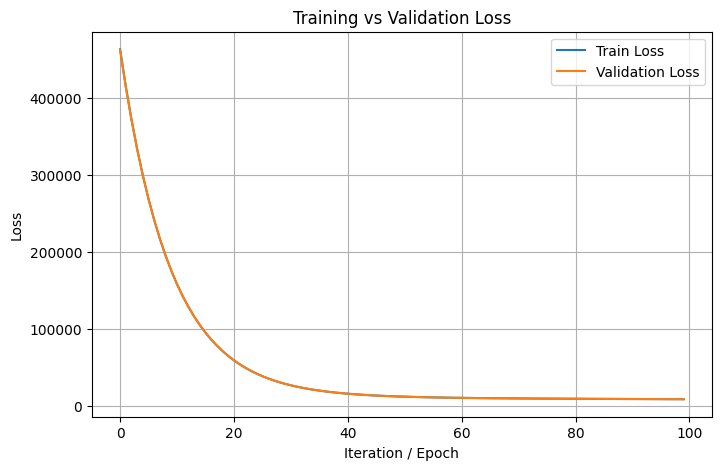

In [17]:
plot_loss_curve(train_loss, val_loss)

Artificially remove 10% of values from one column. Compare median vs KNN imputation. Which gives lower mean absolute error against the true values?


Detect outliers in one numerical column using IQR. Remove outliers. Plot the distribution before and after.

Task
Write a data quality report: which columns have missing values, what percentage, the imputation strategy chosen for each.